## <center><strong>=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=</strong></center>
## <center><strong>[</strong>　AIプログラミングⅡ　ひらがな分類モデル　<strong>]</strong></center>
### <center>25ca0224　<font color=blue>/</font>　申 承訓</center>
#### <center><strong>2026 . 07 . 17</strong></center>
## <center><strong>=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=</strong></center>

## 訓練の際と全く同じテストデータの生成はデータセットをもう一つ生成しないといけないため、
## 本ファイルでデータセットをランダムに取り出しテストデータを生成しました。
## テストデータに学習データも混ざることになるため、評価が高くなります。
## 元のテストデータで評価した汎化性能は下記となります。
## LOSS     : 0.155
## ACCURACY : 0.959

In [1]:
import os
import random
from sklearn.preprocessing import LabelEncoder
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams['font.family'] = 'MS Gothic'

# テストデータ作成のため、データセットをロード

In [2]:
dataset = os.listdir('hiragana/')
scaled_data = np.array([Image.open(f'hiragana/{i_name}') for i_name in dataset])/255
print(scaled_data[0])

label_encoder = LabelEncoder()
labels = [i_name[0] for i_name in dataset]
japanese_labels = sorted(list(set(labels.copy())))
encoded_lables = label_encoder.fit_transform(labels)
print(encoded_lables)

print(len(scaled_data), len(encoded_lables))

[[0.18823529 0.25098039 0.18823529 ... 0.25098039 0.25098039 0.25098039]
 [0.18823529 0.18823529 0.25098039 ... 0.25098039 0.25098039 0.25098039]
 [0.25098039 0.25098039 0.25098039 ... 0.25098039 0.25098039 0.25098039]
 ...
 [0.25098039 0.25098039 0.25098039 ... 0.25098039 0.25098039 0.18823529]
 [0.25098039 0.25098039 0.25098039 ... 0.25098039 0.18823529 0.25098039]
 [0.25098039 0.25098039 0.25098039 ... 0.25098039 0.25098039 0.25098039]]
[ 0  0  0 ... 48 48 48]
6240 6240


# test_size分のRandomテストデータ生成および確認

2000 2000


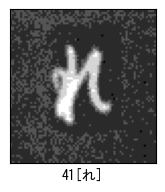

In [3]:
test_size = 2000
test_index = []
test_x = []
test_y = []
for i in range(test_size):
    random_index = random.randint(0,len(scaled_data)-1)
    test_x.append(scaled_data[random_index])
    test_y.append(encoded_lables[random_index])
test_x = np.array(test_x)
test_y = np.array(test_y)

print(len(test_x), len(test_y))
plt.figure(figsize=(2,2))
plt.imshow(test_x[0], cmap='gray')
plt.xlabel(f'{test_y[0]}[{japanese_labels[test_y[0]]}]')
plt.xticks([])
plt.yticks([])
plt.show()

# ロードしたモデルの汎化性能の評価

In [13]:
best_model = load_model('hiragana_classification_model_25ca0224.h5')
# compare_second_model = load_model('027epoch_v_loss0.18_v_acc0.96_model.h5')
# compare_third_model = load_model('083epoch_v_loss0.21_v_acc0.96_model.h5')

In [14]:
bm_loss, bm_acc = best_model.evaluate(test_x, test_y, verbose=0)
# sm_loss, sm_acc = compare_second_model.evaluate(test_x, test_y, verbose=0)
# tm_loss, tm_acc = compare_third_model.evaluate(test_x, test_y, verbose=0)
print('=====================================================')
print()
print(f'Best Model   : LOSS [{bm_loss:.3f}] / ACCURACY [{bm_acc:.3f}]')
print()
print('=====================================================')
# print(f'Second Model : LOSS [{sm_loss:.3f}] / ACCURACY [{sm_acc:.3f}]')
# print(f'Third Model  : LOSS [{tm_loss:.3f}] / ACCURACY [{tm_acc:.3f}]')


Best Model   : LOSS [0.060] / ACCURACY [0.988]



# 評価の際、どのように予測したのか確認

In [15]:
y_pred = best_model.predict(test_x)
y_classes = [np.argmax(y_pred[i]) for i in range(len(y_pred))]

63/63 [==============================] - 2s 22ms/step


In [16]:
y_true = np.array([japanese_labels[true_answer] for true_answer in test_y])
y_pred = np.array([japanese_labels[predicted_answer] for predicted_answer in y_classes])

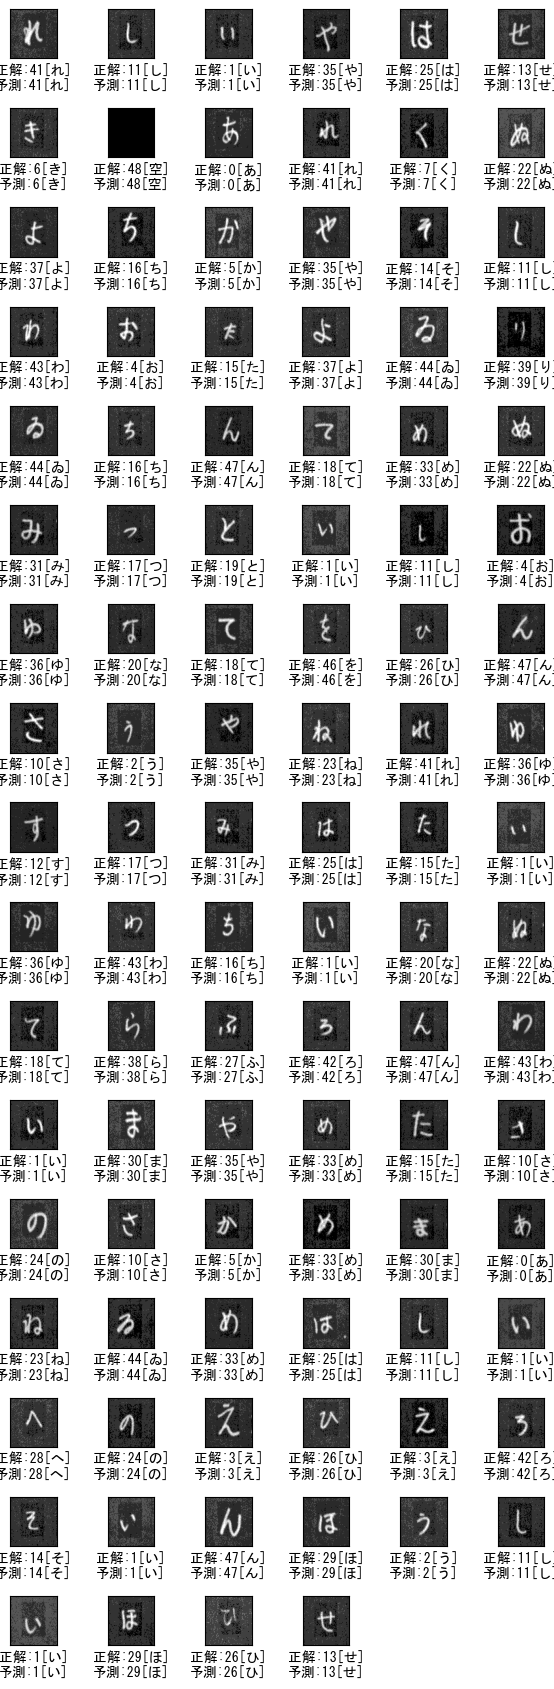

In [17]:
pred_image_axes = []
num_images = len(y_classes[:100])
columns = 6
row = math.ceil(num_images/columns)
fig = plt.figure(figsize=(columns,row))
for i in range(num_images):
    ax = fig.add_subplot(row,columns,i+1)
    if y_classes[i] == test_y[i]:
        ax.set_xlabel(f'正解:{test_y[i]}[{japanese_labels[test_y[i]]}]\n予測:{y_classes[i]}[{japanese_labels[y_classes[i]]}]')
    else:
        ax.set_xlabel(f'正解:{test_y[i]}[{japanese_labels[test_y[i]]}]\n予測:{y_classes[i]}[{japanese_labels[y_classes[i]]}]', color='red')
    ax.set_xticks([])
    ax.set_yticks([])
    pred_image_axes.append(ax)
for i in range(len(pred_image_axes)):
    pred_image_axes[i].imshow(test_x[i], cmap='gray')
plt.tight_layout()
plt.show()

# 今回のテストでの各文字別、正解率を確認 (混同行列、Heatmap)

In [18]:
cm = confusion_matrix(y_true, y_pred, labels=japanese_labels, normalize='true')
print(cm)

[[0.92105263 0.         0.         ... 0.         0.         0.        ]
 [0.         1.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.97560976 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]


In [19]:
correct_rate = []
rate_list = []
for i in range(len(japanese_labels)):
    rate = f'{cm[i][i]:.0%}'
    if len(rate) < 4:
        while len(rate) < 4:
            rate = " " + rate
    if i != 0 and i % 5 == 0:
        correct_rate.append(rate_list)
        rate_list = []
    rate_list.append(f'{japanese_labels[i]} : {rate}')
for i in range(len(correct_rate)):
    print(correct_rate[i])

['あ :  92%', 'い : 100%', 'う :  98%', 'え :  99%', 'お :  93%']
['か : 100%', 'き : 100%', 'く : 100%', 'け : 100%', 'こ : 100%']
['さ : 100%', 'し : 100%', 'す : 100%', 'せ : 100%', 'そ : 100%']
['た :  98%', 'ち : 100%', 'つ : 100%', 'て :  98%', 'と : 100%']
['な :  95%', 'に : 100%', 'ぬ : 100%', 'ね : 100%', 'の :  98%']
['は : 100%', 'ひ :  93%', 'ふ :  94%', 'へ :  97%', 'ほ : 100%']
['ま : 100%', 'み : 100%', 'む : 100%', 'め : 100%', 'も :  96%']
['や : 100%', 'ゆ :  98%', 'よ : 100%', 'ら : 100%', 'り :  97%']
['る :  97%', 'れ : 100%', 'ろ : 100%', 'わ : 100%', 'ゐ :  95%']


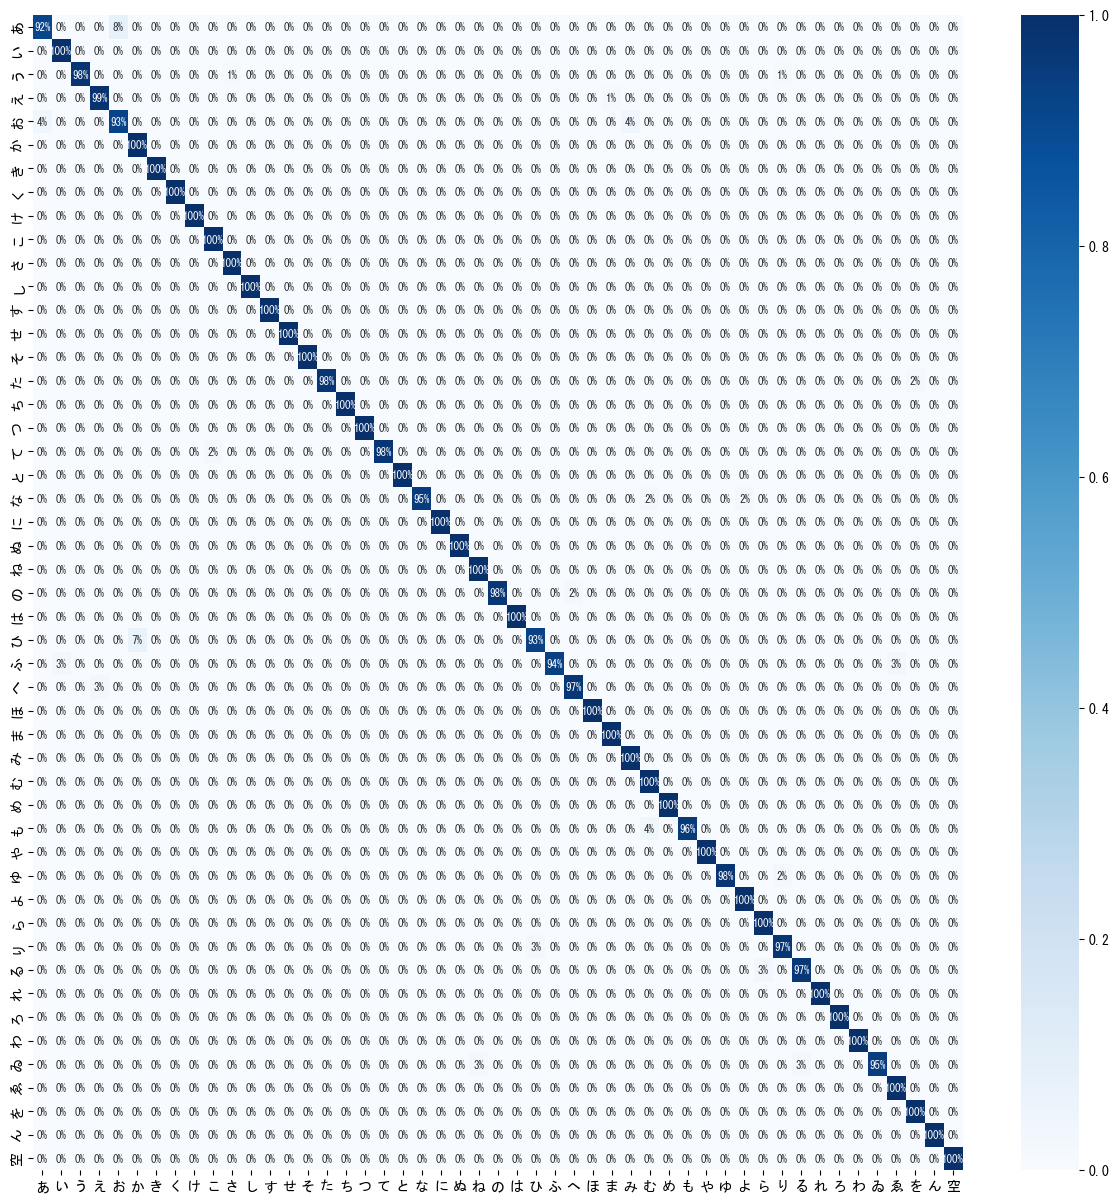

In [20]:
plt.figure(figsize=(15,15))
sns.heatmap(cm, cmap="Blues", annot=True, fmt=".0%", xticklabels=japanese_labels, yticklabels=japanese_labels, annot_kws={"size": 8})
plt.show()